In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur style visualisasi agar terlihat clean dan profesional
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

print("✓ Library berhasil di-import.")

✓ Library berhasil di-import.


In [8]:
# Membaca file CSV hasil eksperimen
try:
    df_exp = pd.read_csv('experiment_results_3.csv')
    df_tp = pd.read_csv('throughput_results_3.csv')
    
    # print("=== Data Experiment Results ===")
    # display(df_exp.head())
    
    # print("\n=== Data Throughput Results ===")
    # display(df_tp.head())
except FileNotFoundError as e:
    print(f"✗ File tidak ditemukan. Pastikan file CSV berada di folder yang sama: {e}")

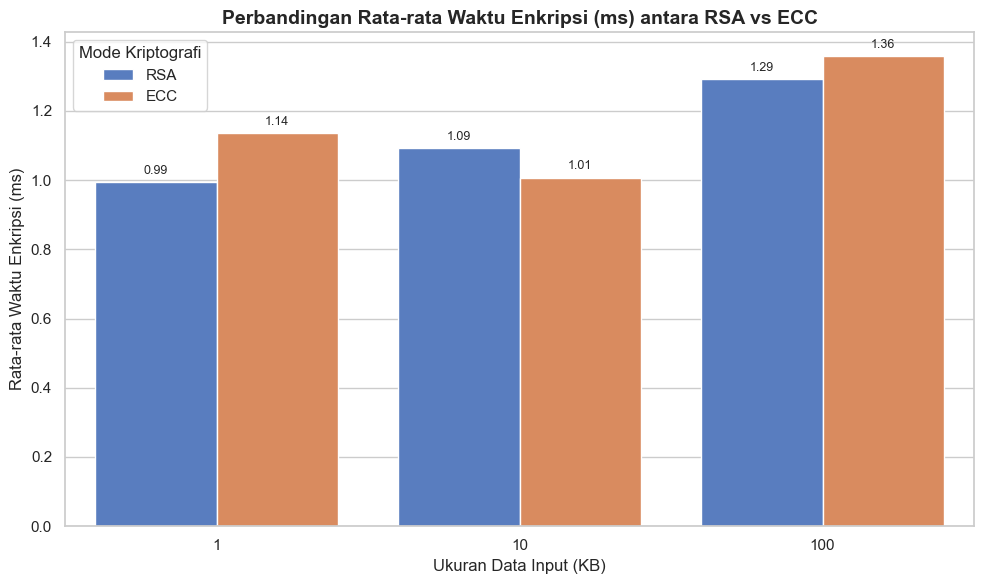

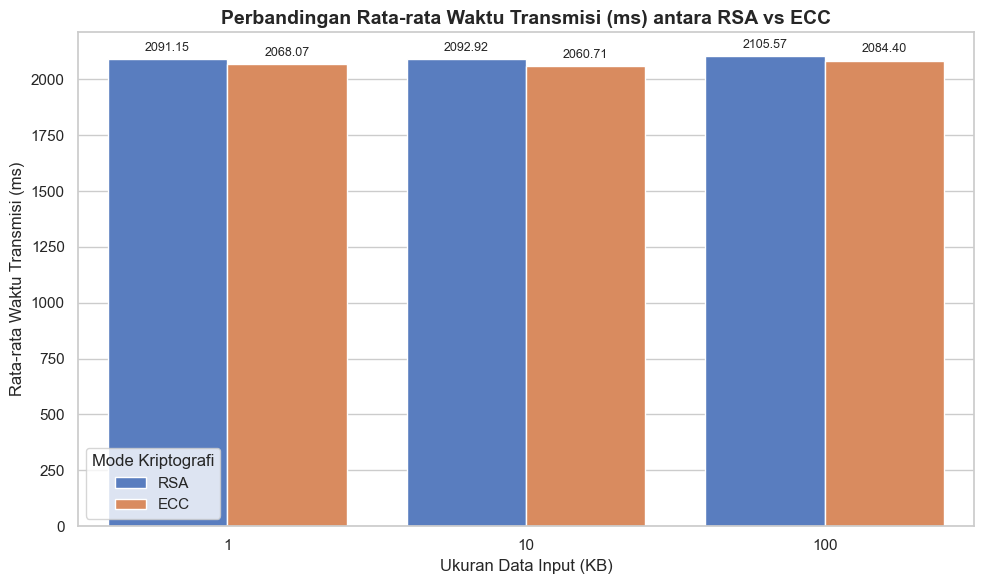

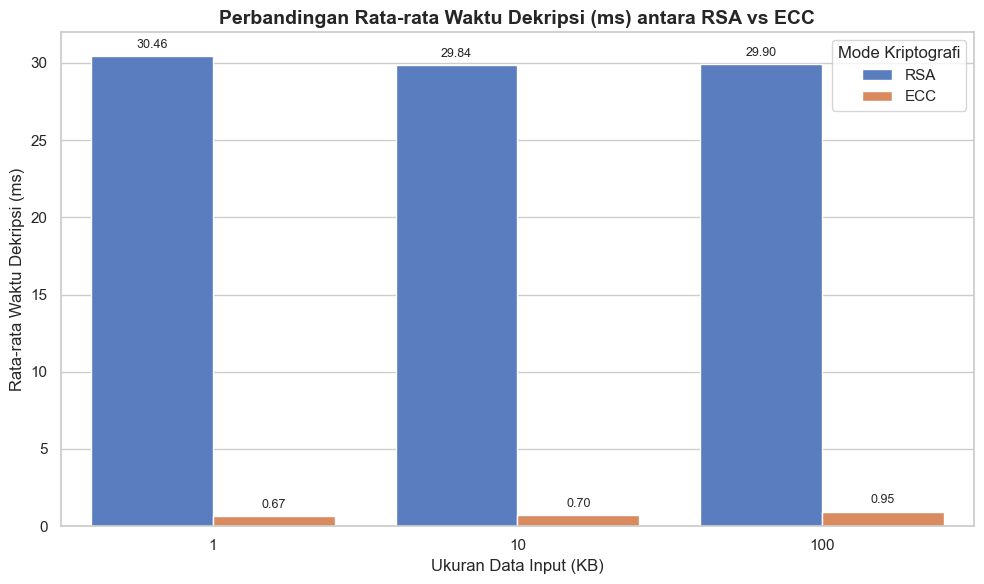

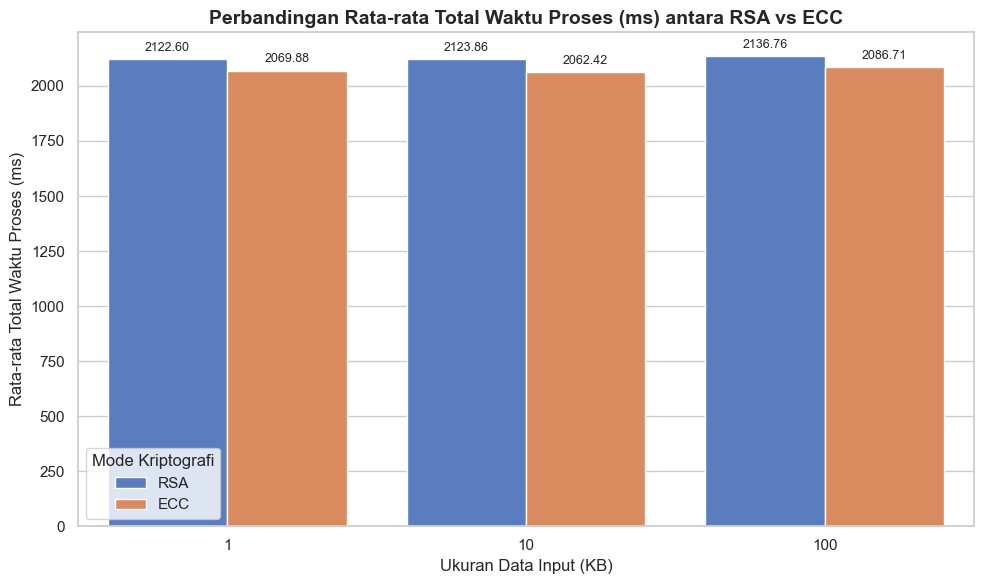

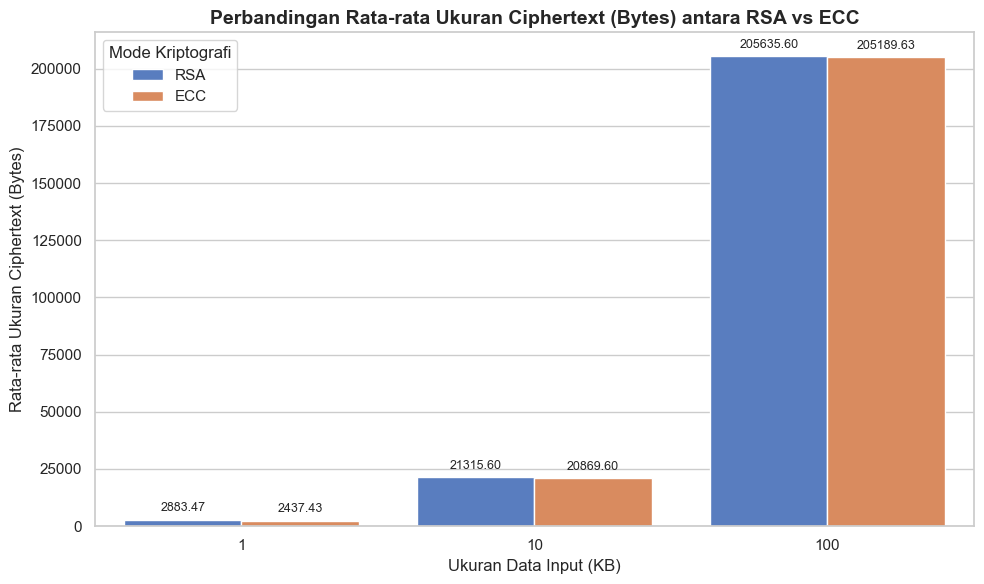

In [9]:
# Styling
sns.set(style='whitegrid')

# =========================================================
# Membuat visualisasi berdasarkan setiap header mean pada CSV
# =========================================================

# Daftar kolom mean yang ingin divisualisasikan
metrics = [
    ('enc_mean_ms', 'Rata-rata Waktu Enkripsi (ms)'),
    ('trans_mean_ms', 'Rata-rata Waktu Transmisi (ms)'),
    ('dec_mean_ms', 'Rata-rata Waktu Dekripsi (ms)'),
    ('total_mean_ms', 'Rata-rata Total Waktu Proses (ms)'),
    ('ct_size_mean_bytes', 'Rata-rata Ukuran Ciphertext (Bytes)')
]

# Loop untuk membuat grafik tiap metrik
for metric, ylabel in metrics:

    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        data=df_exp,
        x='size_kb',
        y=metric,
        hue='mode',
        palette='muted'
    )

    # Judul
    plt.title(
        f'Perbandingan {ylabel} antara RSA vs ECC',
        fontsize=14,
        fontweight='bold'
    )

    # Label sumbu
    plt.xlabel('Ukuran Data Input (KB)', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)

    # Legend
    plt.legend(title='Mode Kriptografi')

    # Menampilkan nilai di atas bar
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(
                f"{p.get_height():.2f}",
                (
                    p.get_x() + p.get_width() / 2.,
                    p.get_height()
                ),
                ha='center',
                va='center',
                xytext=(0, 8),
                textcoords='offset points',
                fontsize=9
            )

    plt.tight_layout()
    plt.show()

In [3]:
print("=== ANALISIS DESKRIPTIF: PERFORMANCE & SIZE ===")
# Mengelompokkan berdasarkan Mode Kriptografi dan Ukuran Data
summary_exp = df_exp.groupby(['mode', 'size_kb']).agg({
    'rtt_mean_ms': 'mean',
    'ct_size_mean_bytes': 'mean'
}).reset_index()
display(summary_exp)

print("\n=== ANALISIS DESKRIPTIF: THROUGHPUT ===")
summary_tp = df_tp.groupby(['mode', 'size_kb'])['throughput_msg_per_sec'].mean().reset_index()
display(summary_tp)

=== ANALISIS DESKRIPTIF: PERFORMANCE & SIZE ===


,mode,size_kb,rtt_mean_ms,ct_size_mean_bytes
0,ECC,1,4111.0627,2419.7
1,ECC,10,4111.6632,20851.7
2,ECC,100,4123.9447,205171.7
3,RSA,1,4143.3921,2865.7
4,RSA,10,4145.6325,21297.7
5,RSA,100,4202.5674,205617.7



=== ANALISIS DESKRIPTIF: THROUGHPUT ===


,mode,size_kb,throughput_msg_per_sec
0,ECC,1,0.3
1,ECC,10,0.3
2,ECC,100,0.3
3,RSA,1,0.3
4,RSA,10,0.3
5,RSA,100,0.3


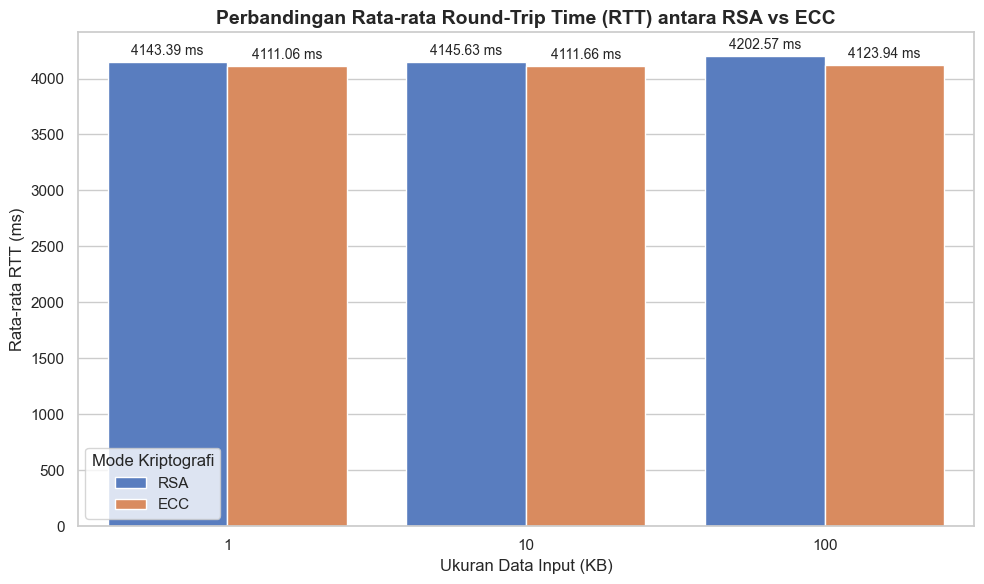

In [4]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_exp, 
    x='size_kb', 
    y='rtt_mean_ms', 
    hue='mode', 
    palette='muted'
)

# Menambahkan error bar manual berdasarkan rtt_stdev_ms jika diperlukan, 
# namun seaborn barplot standar sudah cukup merepresentasikan mean.
plt.title('Perbandingan Rata-rata Round-Trip Time (RTT) antara RSA vs ECC', fontsize=14, fontweight='bold')
plt.xlabel('Ukuran Data Input (KB)', fontsize=12)
plt.ylabel('Rata-rata RTT (ms)', fontsize=12)
plt.legend(title='Mode Kriptografi')

# Menampilkan nilai di atas bar
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.2f} ms", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

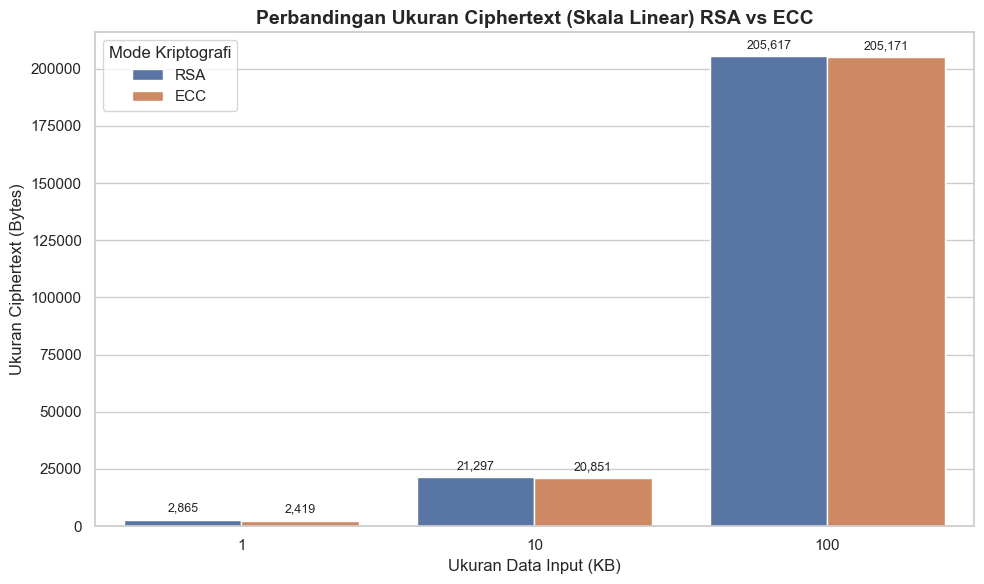

In [5]:
plt.figure(figsize=(10, 6))
# Menggunakan skala logaritmik karena perbedaan ukuran data (1KB, 10KB, 100KB) sangat signifikan
ax = sns.barplot(
    data=df_exp, 
    x='size_kb', 
    y='ct_size_mean_bytes', 
    hue='mode', 
    palette='deep'
)

plt.title('Perbandingan Ukuran Ciphertext (Skala Linear) RSA vs ECC', fontsize=14, fontweight='bold')
plt.xlabel('Ukuran Data Input (KB)', fontsize=12)
plt.ylabel('Ukuran Ciphertext (Bytes)', fontsize=12)
plt.legend(title='Mode Kriptografi')

# Menampilkan nilai asli di atas bar
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{int(p.get_height()):,}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

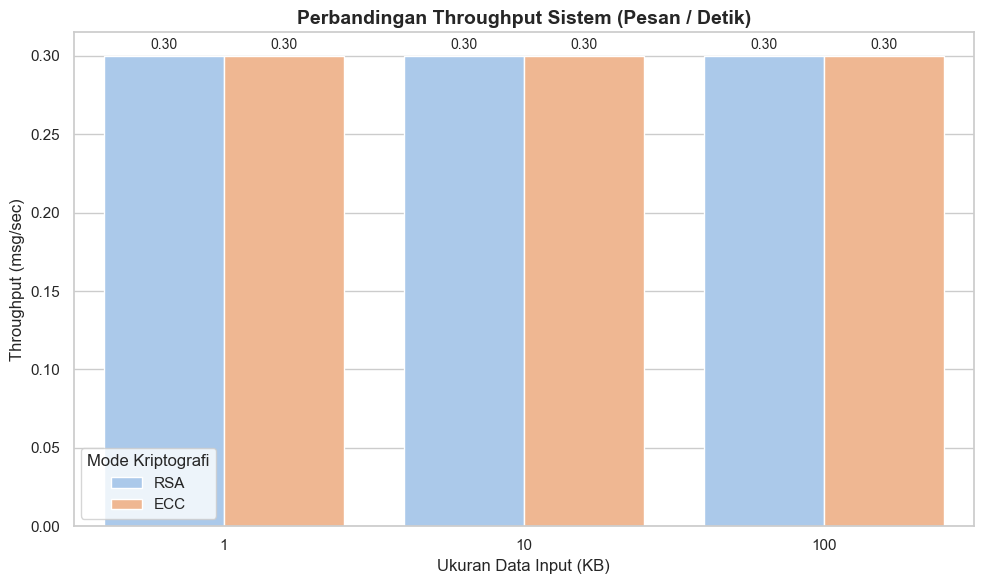

In [6]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_tp, 
    x='size_kb', 
    y='throughput_msg_per_sec', 
    hue='mode', 
    palette='pastel'
)

plt.title('Perbandingan Throughput Sistem (Pesan / Detik)', fontsize=14, fontweight='bold')
plt.xlabel('Ukuran Data Input (KB)', fontsize=12)
plt.ylabel('Throughput (msg/sec)', fontsize=12)
plt.legend(title='Mode Kriptografi')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.2f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 8), 
                    textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

### 📝 Kesimpulan Hasil Eksperimen Kinerja:

1. **Round-Trip Time (RTT):**
   * Berdasarkan data, **ECC Mode** secara konsisten menghasilkan RTT yang sedikit lebih cepat/rendah (~4112ms - 4134ms) dibandingkan dengan **RSA Mode** (~4142ms - 4161ms). Hal ini membuktikan efisiensi komputasi dari algoritma berbasis kurva eliptik (X25519) pada perangkat Edge.

2. **Ukuran Ciphertext (Ciphertext Size):**
   * **ECC Mode** menghasilkan ukuran ciphertext yang lebih ringkas dibandingkan **RSA Mode**, terutama pada ukuran file kecil (1KB). Hal ini disebabkan oleh ukuran public key dan overhead enkripsi X25519 yang lebih kecil dibandingkan modular exponentiation pada RSA-2048.

3. **Throughput:**
   * Di lingkungan simulasi berdurasi 10 detik ini, kedua mode mencatatkan throughput yang identik (0.3 pesan/detik dengan total 3 sukses). Hal ini dipengaruhi oleh batasan interval pengiriman (*sleep/delay time*) atau sinkronisasi komunikasi pada script pengujian.